# HNSW 在 NetVLAD 特征上的性能分析

流程：读取 NetVLAD H5 → FAISS 生成真值 → 网格搜索 M / efConstruction / efSearch → 画图（Recall、时间、参数影响）

**说明**：当前参数范围按 **db/query 各几百条** 的小规模数据设定（efSearch、M、efConstruction 已缩小），跑得快且仍能看出趋势。数据量变大后可适当提高各参数上限。

In [1]:
import sys
from pathlib import Path

# 确保能导入 ch3 下的 demo_readH5（若 kernel 的 cwd 是 hnsw_performance_analysis）
_nb_dir = Path().resolve()
if _nb_dir.name == "hnsw_performance_analysis":
    sys.path.insert(0, str(_nb_dir.parent))

import numpy as np
import faiss
import matplotlib.pyplot as plt
import time

from demo_readH5 import load_netvlad_descriptors, load_multi_netvlad_descriptors, DB_H5_PATHS, QUERY_H5_PATH

## 1. 读取 NetVLAD H5（合并多个 DB 文件）

In [2]:
# 将多个 DB H5 合并为一个大数据库
print("从多个 DB H5 读取并合并 NetVLAD 描述子...")
db_names, db_descs = load_multi_netvlad_descriptors(DB_H5_PATHS)

print("从单一 Query H5 读取 NetVLAD 描述子...")
query_names, query_descs = load_netvlad_descriptors(QUERY_H5_PATH)

db_descs = db_descs.astype(np.float32)
query_descs = query_descs.astype(np.float32)

print(f"DB (multi):    {len(db_names)} 条, shape {db_descs.shape}")
print(f"Query (single): {len(query_names)} 条, shape {query_descs.shape}")

从多个 DB H5 读取并合并 NetVLAD 描述子...
从单一 Query H5 读取 NetVLAD 描述子...
DB (multi):    734 条, shape (734, 4096)
Query (single): 362 条, shape (362, 4096)


## 2. 用 FAISS 暴力检索生成 Ground Truth（精确 L2 最近邻）

In [3]:
# 数据量较小时 K_GT 不超过 db 大小，且一般用 Recall@5 或 @10 即可
K_GT = min(10, len(db_descs))

d = db_descs.shape[1]
index_gt = faiss.IndexFlatL2(d)
index_gt.add(db_descs)

D_gt, I_gt = index_gt.search(query_descs, K_GT)
print(f"Ground truth: K_GT={K_GT}, I_gt {I_gt.shape}, D_gt {D_gt.shape}")

Ground truth: K_GT=10, I_gt (362, 10), D_gt (362, 10)


## 3. Recall@k 与计时辅助函数

In [4]:
def recall_at_k(pred_I: np.ndarray, gt_I: np.ndarray, k: int) -> float:
    """pred_I: (N_q, topk), gt_I: (N_q, K_GT)。计算 Recall@k（预测的 top-k 与真值 top-k 的交集比例）。"""
    nq = pred_I.shape[0]
    gt_topk = set(range(min(k, gt_I.shape[1])))
    recalls = []
    for i in range(nq):
        pred_set = set(pred_I[i, :k])
        gt_set = set(gt_I[i, :k])
        if len(gt_set) == 0:
            recalls.append(1.0)
        else:
            recalls.append(len(pred_set & gt_set) / len(gt_set))
    return float(np.mean(recalls))


def build_hnsw_and_search(db: np.ndarray, q: np.ndarray, k: int, M: int, ef_c: int, ef_s: int):
    """构建 HNSW 索引并检索，返回 (I, D, 建索引耗时, 查询总耗时)。"""
    d = db.shape[1]
    index = faiss.IndexHNSWFlat(d, M)
    index.hnsw.efConstruction = ef_c
    index.hnsw.efSearch = ef_s
    t0 = time.perf_counter()
    index.add(db)
    t_build = time.perf_counter() - t0
    t1 = time.perf_counter()
    D, I = index.search(q, k)
    t_search = time.perf_counter() - t1
    return I, D, t_build, t_search

## 4. 网格搜索：efSearch 对 Recall 与 查询时间 的影响

In [17]:
# 小规模数据（几百条）：M 和 efSearch 不必过大，便于快速跑完
M_fixed = 24
ef_construction_fixed = 150
ef_search_values = [1, 5, 10, 20, 50, 100, 150, 200]
k_eval = min(10, K_GT)

recalls_ef = []
times_per_query_ms = []

for ef_s in ef_search_values:
    I, D, t_build, t_search = build_hnsw_and_search(
        db_descs, query_descs, k_eval,
        M=M_fixed, ef_c=ef_construction_fixed, ef_s=ef_s
    )
    r = recall_at_k(I, I_gt, k_eval)
    recalls_ef.append(r)
    t_pq = (t_search / len(query_descs)) * 1000
    times_per_query_ms.append(t_pq)
    print(f"efSearch={ef_s:4d}  Recall@{k_eval}={r:.4f}  time/query={t_pq:.4f} ms")

recalls_ef = np.array(recalls_ef)
times_per_query_ms = np.array(times_per_query_ms)

efSearch=   1  Recall@10=0.4641  time/query=0.0057 ms
efSearch=   5  Recall@10=0.7992  time/query=0.0092 ms
efSearch=  10  Recall@10=0.9257  time/query=0.0095 ms
efSearch=  20  Recall@10=0.9710  time/query=0.0134 ms
efSearch=  50  Recall@10=0.9970  time/query=0.0293 ms
efSearch= 100  Recall@10=0.9997  time/query=0.0389 ms
efSearch= 150  Recall@10=1.0000  time/query=0.0534 ms
efSearch= 200  Recall@10=1.0000  time/query=0.0584 ms


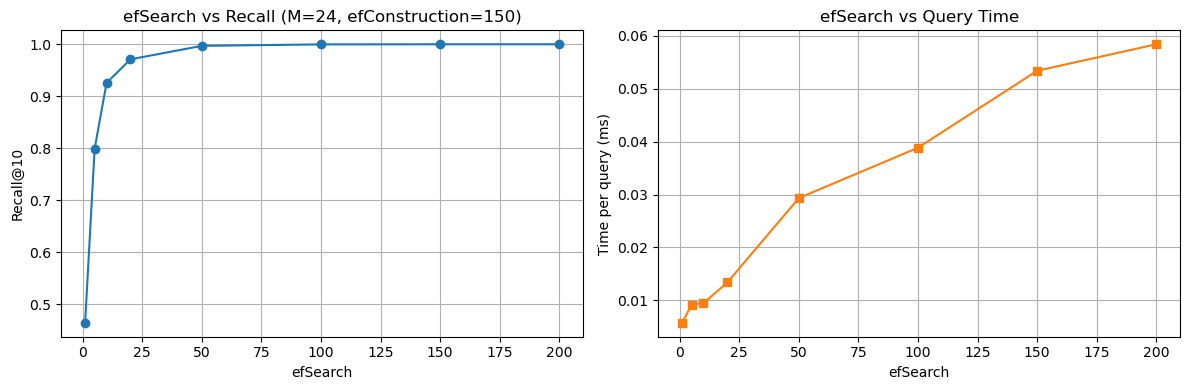

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ef_search_values, recalls_ef, marker="o")
ax1.set_xlabel("efSearch")
ax1.set_ylabel(f"Recall@{k_eval}")
ax1.set_title(f"efSearch vs Recall (M={M_fixed}, efConstruction={ef_construction_fixed})")
ax1.grid(True)

ax2.plot(ef_search_values, times_per_query_ms, marker="s", color="C1")
ax2.set_xlabel("efSearch")
ax2.set_ylabel("Time per query (ms)")
ax2.set_title("efSearch vs Query Time")
ax2.grid(True)

plt.tight_layout()
plt.show()

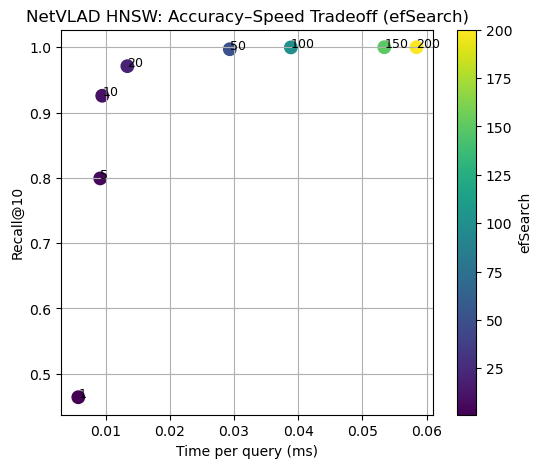

In [19]:
# 精度-速度权衡：Recall vs Time per query
plt.figure(figsize=(6, 5))
plt.scatter(times_per_query_ms, recalls_ef, s=80, c=ef_search_values, cmap="viridis")
for i, ef in enumerate(ef_search_values):
    plt.annotate(str(ef), (times_per_query_ms[i], recalls_ef[i]), fontsize=9)
plt.xlabel("Time per query (ms)")
plt.ylabel(f"Recall@{k_eval}")
plt.title("NetVLAD HNSW: Accuracy–Speed Tradeoff (efSearch)")
plt.colorbar(label="efSearch")
plt.grid(True)
plt.show()

## 5. 参数 M 与 efConstruction 的影响（网格搜索）

In [20]:
# 小规模数据：M 用 8~32，efConstruction 用 50~200 即可
ef_search_fixed = 20
M_values = [8, 16, 24, 32]
ef_construction_values = [20, 50, 100, 200]

results_M_efC = []  # list of (M, ef_c, recall, time_per_query_ms)

for M in M_values:
    for ef_c in ef_construction_values:
        I, D, t_build, t_search = build_hnsw_and_search(
            db_descs, query_descs, k_eval,
            M=M, ef_c=ef_c, ef_s=ef_search_fixed
        )
        r = recall_at_k(I, I_gt, k_eval)
        t_pq = (t_search / len(query_descs)) * 1000
        results_M_efC.append((M, ef_c, r, t_pq))
        print(f"M={M}, efConstruction={ef_c}  Recall@{k_eval}={r:.4f}  time/query={t_pq:.4f} ms")

results_M_efC = np.array(results_M_efC)

M=8, efConstruction=20  Recall@10=0.8845  time/query=0.0061 ms
M=8, efConstruction=50  Recall@10=0.9373  time/query=0.0085 ms
M=8, efConstruction=100  Recall@10=0.9544  time/query=0.0086 ms
M=8, efConstruction=200  Recall@10=0.9613  time/query=0.0110 ms
M=16, efConstruction=20  Recall@10=0.8704  time/query=0.0085 ms
M=16, efConstruction=50  Recall@10=0.9486  time/query=0.0116 ms
M=16, efConstruction=100  Recall@10=0.9544  time/query=0.0124 ms
M=16, efConstruction=200  Recall@10=0.9586  time/query=0.0124 ms
M=24, efConstruction=20  Recall@10=0.9174  time/query=0.0128 ms
M=24, efConstruction=50  Recall@10=0.9503  time/query=0.0118 ms
M=24, efConstruction=100  Recall@10=0.9699  time/query=0.0110 ms
M=24, efConstruction=200  Recall@10=0.9738  time/query=0.0132 ms
M=32, efConstruction=20  Recall@10=0.9456  time/query=0.0161 ms
M=32, efConstruction=50  Recall@10=0.9613  time/query=0.0190 ms
M=32, efConstruction=100  Recall@10=0.9680  time/query=0.0126 ms
M=32, efConstruction=200  Recall@10=0

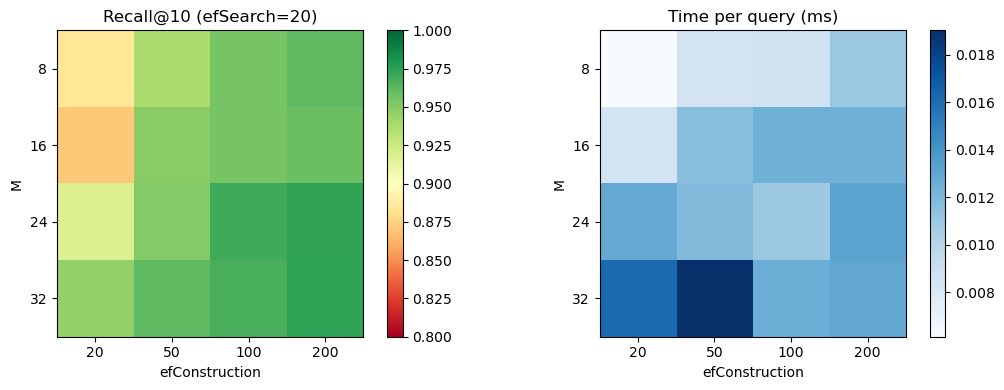

In [23]:
# Recall 热力图：M x efConstruction
recall_grid = np.zeros((len(M_values), len(ef_construction_values)))
time_grid = np.zeros((len(M_values), len(ef_construction_values)))
idx = 0
for i, M in enumerate(M_values):
    for j, ef_c in enumerate(ef_construction_values):
        recall_grid[i, j] = results_M_efC[idx, 2]
        time_grid[i, j] = results_M_efC[idx, 3]
        idx += 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

im1 = ax1.imshow(recall_grid, cmap="RdYlGn", vmin=0.8, vmax=1)
ax1.set_xticks(range(len(ef_construction_values)))
ax1.set_xticklabels(ef_construction_values)
ax1.set_yticks(range(len(M_values)))
ax1.set_yticklabels(M_values)
ax1.set_xlabel("efConstruction")
ax1.set_ylabel("M")
ax1.set_title(f"Recall@{k_eval} (efSearch={ef_search_fixed})")
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(time_grid, cmap="Blues")
ax2.set_xticks(range(len(ef_construction_values)))
ax2.set_xticklabels(ef_construction_values)
ax2.set_yticks(range(len(M_values)))
ax2.set_yticklabels(M_values)
ax2.set_xlabel("efConstruction")
ax2.set_ylabel("M")
ax2.set_title("Time per query (ms)")
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

## 6. 综合：多条 efSearch 曲线（不同 M）

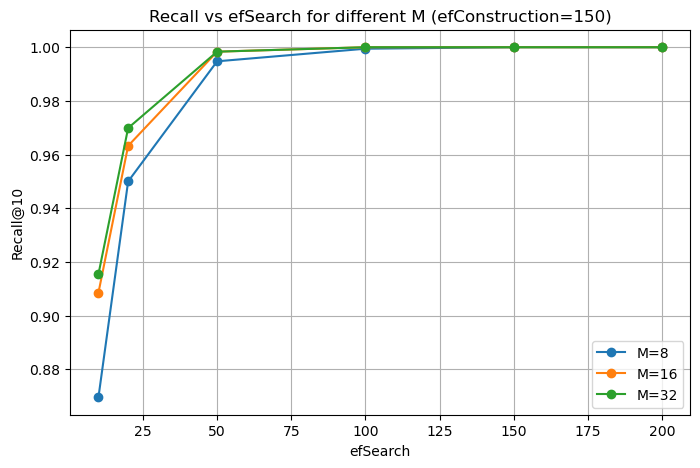

In [24]:
ef_search_list = [10, 20, 50, 100, 150, 200]
M_list_for_curves = [8, 16, 32]
ef_c_fixed = 150

plt.figure(figsize=(8, 5))
for M in M_list_for_curves:
    recs = []
    for ef_s in ef_search_list:
        I, _, _, t_search = build_hnsw_and_search(
            db_descs, query_descs, k_eval,
            M=M, ef_c=ef_c_fixed, ef_s=ef_s
        )
        recs.append(recall_at_k(I, I_gt, k_eval))
    plt.plot(ef_search_list, recs, marker="o", label=f"M={M}")

plt.xlabel("efSearch")
plt.ylabel(f"Recall@{k_eval}")
plt.title(f"Recall vs efSearch for different M (efConstruction={ef_c_fixed})")
plt.legend()
plt.grid(True)
plt.show()

## 7. 小结

- **efSearch**：越大 Recall 越高、查询越慢；可根据目标 Recall 与延迟要求选取。
- **M**：越大图越密，通常 Recall 略升、建索引与查询略慢。
- **efConstruction**：越大建索引越慢、图质量越好，对查询阶段 Recall 有正向影响。